In [62]:
import numpy as np
import adi
import time

def pluto_capture_iq(
    uri="ip:pluto.local",
    center_hz=2.4065e9,
    sample_rate=2_300_000,
    rf_bandwidth=1_000_000,
    gain_mode="manual",        # "manual" or "slow_attack"
    gain_db=8,
    num_samples=2_300_000,     # 1 second at 2.3 MS/s
    warmup_reads=2,
):
    """
    Returns complex64 IQ array of length num_samples (approximately).
    """
    sdr = adi.Pluto(uri)

    # RX configuration
    sdr.rx_lo = int(center_hz)
    sdr.sample_rate = int(sample_rate)
    sdr.rx_rf_bandwidth = int(rf_bandwidth)

    sdr.gain_control_mode_chan0 = gain_mode
    if gain_mode == "manual":
        sdr.rx_hardwaregain_chan0 = float(gain_db)

    # Buffering
    # rx_buffer_size controls how many samples you get per read().
    # Using a moderate chunk size is reliable.
    chunk = 262144
    sdr.rx_buffer_size = chunk

    # Warm up (let LO/filters settle)
    for _ in range(warmup_reads):
        _ = sdr.rx()

    # Capture in chunks
    iq = np.empty(num_samples, dtype=np.complex64)
    got = 0
    while got < num_samples:
        x = sdr.rx().astype(np.complex64)
        n = min(len(x), num_samples - got)
        iq[got:got+n] = x[:n]
        got += n

    return iq


In [95]:
Fs = 2_300_000
iq = pluto_capture_iq(
    uri="ip:pluto.local",
    center_hz=2.405e9,
    sample_rate=Fs,
    rf_bandwidth=1_000_000,
    gain_mode="manual",
    gain_db=20,
    num_samples=Fs * 2,   # 2 seconds
)
print(iq.shape, iq.dtype)


(4600000,) complex64


In [110]:
Fs = 2_300_000
iq = pluto_capture_iq(
    uri="ip:pluto.local",
    center_hz=2.450e9,
    sample_rate=Fs,
    rf_bandwidth=1_000_000,
    gain_mode="manual",
    gain_db=20,
    num_samples=Fs * 2,   # 2 seconds
)
print(iq.shape, iq.dtype)

(4600000,) complex64


In [111]:
import matplotlib.pyplot as plt

def quick_mag_plot(iq, Fs, seconds=0.05):
    n = int(Fs * seconds)
    m = np.abs(iq[:n])
    t = np.arange(len(m)) / Fs
    plt.figure()
    plt.plot(t*1e3, m)
    plt.xlabel("Time (ms)")
    plt.ylabel("|IQ|")
    plt.show()


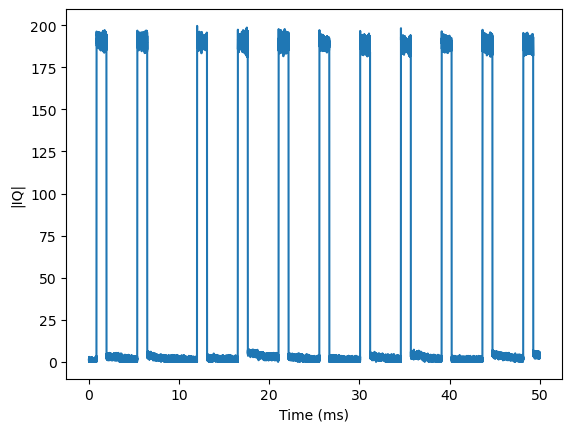

In [112]:
quick_mag_plot(iq, Fs, seconds=0.05)

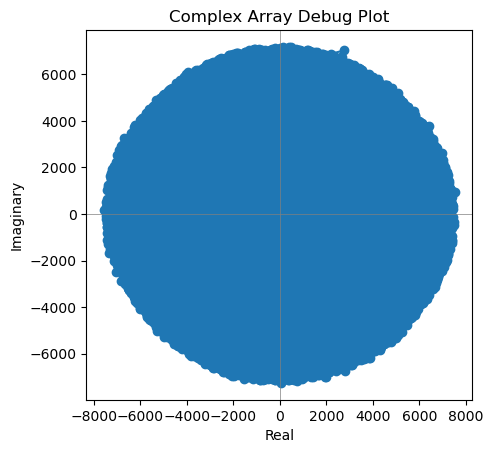

In [115]:
import numpy as np
import matplotlib.pyplot as plt

z = iq[::100]

plt.plot(z.real, z.imag, marker='o')
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.gca().set_aspect('equal')
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title("Complex Array Debug Plot")
plt.show()

In [72]:
iq[:20]

array([ 1.-1.j,  0.+1.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+1.j,
        1.+0.j,  0.+1.j,  0.+1.j, -1.+1.j,  0.+1.j,  0.+1.j,  1.+1.j,
        1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+1.j,  0.+0.j],
      dtype=complex64)

# Replay iq

In [73]:
def limit_to_pluto_dac(iq, headroom=0.7):
    """
    Pluto DAC is effectively 14-bit signed.
    We scale down if the file exceeds that, otherwise keep as-is.
    """
    max_allowed = int((2**13 - 1) * headroom)  # ~8191 * headroom
    print(max_allowed)
    peak = int(np.max(np.abs(np.real(iq)).astype(np.int32).clip(min=0)) if iq.size else 0)
    peak = max(peak, int(np.max(np.abs(np.imag(iq)).astype(np.int32).clip(min=0)) if iq.size else 0))
    print(peak)

    #if peak <= max_allowed or peak == 0:
    #    return iq

    scale = max_allowed / peak
    print(scale)
    i = np.round(np.real(iq).astype(np.float32) * scale).astype(np.int16)
    q = np.round(np.imag(iq).astype(np.float32) * scale).astype(np.int16)
    return i + 1j*q

In [114]:
iq = limit_to_pluto_dac(iq)

7781
207
37.589371980676326


In [120]:
import numpy as np
import adi
import time

URI = "ip:pluto.local"
#CENTER_HZ = 2_405_000_000
CENTER_HZ = 1_605_000_000
#CENTER_HZ = 2_450_000_000
SAMPLE_RATE = 2_300_000
TX_GAIN_DB = -5       
RF_BW = 1_000_000
RF_BW = 1_000_000

sdr = adi.Pluto(URI)

# --- TX config (set BEFORE tx()) ---
sdr.sample_rate = int(SAMPLE_RATE)
sdr.tx_lo = int(CENTER_HZ)
sdr.tx_rf_bandwidth = int(RF_BW)
sdr.tx_hardwaregain_chan0 = float(TX_GAIN_DB)

# IMPORTANT: stop anything old
try:
    sdr.tx_destroy_buffer()
except Exception:
    pass

# Enable cyclic buffer
sdr.tx_cyclic_buffer = True 

# Start TX (this should now loop forever)
sdr.tx(iq)

print("Tone TX running (cyclic). Ctrl+C to stop.")
print("RF MHz:", CENTER_HZ/1e6, " Gain dB:", TX_GAIN_DB)

try:
    while True:
        time.sleep(1)
except KeyboardInterrupt:
    pass
finally:
    print('Exit')
    sdr.tx_destroy_buffer()


Tone TX running (cyclic). Ctrl+C to stop.
RF MHz: 1605.0  Gain dB: -5
Exit


In [7]:
import numpy as np
import adi
import time

# -------------------------
# Record: stream to .cfile
# -------------------------
def pluto_record_cfile(
    filename,
    uri="ip:pluto.local",
    center_hz=2.4065e9,
    sample_rate=2_300_000,
    rf_bandwidth=1_000_000,
    gain_mode="manual",          # "manual" or "slow_attack"
    gain_db=8,
    seconds=1.0,
    rx_buffer_size=262144,
    warmup_reads=2,
):
    sdr = adi.Pluto(uri)

    sdr.rx_lo = int(center_hz)
    sdr.sample_rate = int(sample_rate)
    sdr.rx_rf_bandwidth = int(rf_bandwidth)
    sdr.gain_control_mode_chan0 = gain_mode
    if gain_mode == "manual":
        sdr.rx_hardwaregain_chan0 = float(gain_db)

    sdr.rx_buffer_size = int(rx_buffer_size)

    # settle
    for _ in range(warmup_reads):
        _ = sdr.rx()

    target = int(seconds * sample_rate)
    written = 0

    with open(filename, "wb") as f:
        while written < target:
            x = sdr.rx().astype(np.complex64)
            n = min(len(x), target - written)

            interleaved = np.empty(2 * n, dtype=np.float32)
            interleaved[0::2] = x[:n].real.astype(np.float32)
            interleaved[1::2] = x[:n].imag.astype(np.float32)
            interleaved.tofile(f)

            written += n

    return written


# -------------------------
# Read .cfile -> complex64
# -------------------------
def read_cfile_complex64(filename):
    raw = np.fromfile(filename, dtype=np.float32)
    if len(raw) % 2:
        raw = raw[:-1]
    i = raw[0::2]
    q = raw[1::2]
    return (i + 1j * q).astype(np.complex64)


# ----------------------------------------
# Replay: continuous loop (cyclic buffer)
# ----------------------------------------
def pluto_tx_loop_cfile(
    filename,
    uri="ip:pluto.local",
    center_hz=2.4065e9,
    sample_rate=2_300_000,
    rf_bandwidth=1_000_000,
    tx_gain_db=-30,              # start low (more negative) then increase carefully
    max_abs=0.5,                 # normalize peak magnitude to this
):
    iq = read_cfile_complex64(filename)
    if iq.size == 0:
        raise ValueError("IQ file is empty")

    # Normalize to avoid DAC clipping/splatter
    peak = float(np.max(np.abs(iq)))
    if peak > 0:
        iq = iq * (max_abs / peak)

    sdr = adi.Pluto(uri)
    sdr.sample_rate = int(sample_rate)
    sdr.tx_rf_bandwidth = int(rf_bandwidth)
    sdr.tx_lo = int(center_hz)
    sdr.tx_hardwaregain_chan0 = float(tx_gain_db)

    # Continuous replay
    sdr.tx_cyclic_buffer = True
    sdr.tx(iq)

    print("TX looping... Press Ctrl+C to stop.")
    try:
        while True:
            time.sleep(0.5)
    except KeyboardInterrupt:
        print("Stopping TX.")
    finally:
        # IMPORTANT: stops transmission
        sdr.tx_destroy_buffer()


# ---------------
# Example usage
# ---------------
# 1) Record 2 seconds
# n = pluto_record_cfile("capture.cfile", seconds=2.0)
# print("Recorded samples:", n)

# 2) Loop forever
# pluto_tx_loop_cfile("capture.cfile", tx_gain_db=-20, max_abs=0.4)


In [13]:
n = pluto_record_cfile("capture.cfile", seconds=2.0)
print("Recorded samples:", n)

Recorded samples: 4600000


In [16]:
pluto_tx_loop_cfile("capture.cfile", tx_gain_db=-20, max_abs=0.4)

TX looping... Press Ctrl+C to stop.
Stopping TX.


In [23]:
import numpy as np
import adi
import time

def pluto_tx_tone_and_rx_check(
    uri="ip:pluto.local",
    center_hz=2.4065e9,
    sample_rate=2_000_000,
    tone_hz=100_000,         # tone offset from center
    tx_gain_db=-60,
    rx_gain_db=8,
    rf_bw=1_000_000,
    seconds=0.2,
):
    sdr = adi.Pluto(uri)

    # --- Configure RX ---
    sdr.rx_lo = int(center_hz)
    sdr.sample_rate = int(sample_rate)
    sdr.rx_rf_bandwidth = int(rf_bw)
    sdr.gain_control_mode_chan0 = "manual"
    sdr.rx_hardwaregain_chan0 = float(rx_gain_db)
    sdr.rx_buffer_size = 262144

    # --- Configure TX ---
    sdr.tx_lo = int(center_hz)
    sdr.tx_rf_bandwidth = int(rf_bw)
    sdr.tx_hardwaregain_chan0 = float(tx_gain_db)
    sdr.tx_cyclic_buffer = True

    # Generate complex tone
    n = int(sample_rate * seconds)
    t = np.arange(n) / sample_rate
    iq = 0.3 * np.exp(1j * 2*np.pi*tone_hz*t).astype(np.complex64)

    # Start TX
    sdr.tx(iq)

    # Let it run briefly
    time.sleep(2.0)

    # Grab RX chunk
    x = sdr.rx().astype(np.complex64)

    # Stop TX
    sdr.tx_destroy_buffer()

    # Compute a quick FFT peak frequency
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(len(x), 1/sample_rate))
    peak_hz = f[np.argmax(np.abs(X))]

    print("Detected peak near (Hz):", peak_hz)
    print("Mean |x|:", float(np.mean(np.abs(x))), " Max |x|:", float(np.max(np.abs(x))))

# Run it
# Tip: if you have a coax+atten path, keep tx_gain_db like -20 to -10.
pluto_tx_tone_and_rx_check()


Detected peak near (Hz): 45.7763671875
Mean |x|: 0.5813206434249878  Max |x|: 4.123105525970459


In [24]:
import numpy as np
import adi
import time

def tone_tx_rx_peak(
    uri="ip:pluto.local",
    center_hz=2_406_500_000,
    sample_rate=2_000_000,
    tone_hz=100_000,
    rf_bw=1_000_000,
    tx_gain_db=-50,     # START LOW to avoid overload
    rx_gain_db=0,       # START LOW
    tx_amp=0.05,        # small baseband amplitude
    rx_buffer_size=262144,
):
    sdr = adi.Pluto(uri)

    # RX
    sdr.rx_lo = int(center_hz)
    sdr.sample_rate = int(sample_rate)
    sdr.rx_rf_bandwidth = int(rf_bw)
    sdr.gain_control_mode_chan0 = "manual"
    sdr.rx_hardwaregain_chan0 = float(rx_gain_db)
    sdr.rx_buffer_size = int(rx_buffer_size)

    # TX
    sdr.tx_lo = int(center_hz)
    sdr.tx_rf_bandwidth = int(rf_bw)
    sdr.tx_hardwaregain_chan0 = float(tx_gain_db)
    sdr.tx_cyclic_buffer = True

    # Tone
    n = int(sample_rate * 0.2)
    t = np.arange(n) / sample_rate
    iq = (tx_amp * np.exp(1j * 2*np.pi*tone_hz*t)).astype(np.complex64)

    # Start TX
    sdr.tx(iq)
    time.sleep(0.05)

    # Read RX
    x = sdr.rx().astype(np.complex64)

    # Stop TX
    sdr.tx_destroy_buffer()

    # Remove DC / leakage offset
    x = x - np.mean(x)

    # FFT peak
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(len(x), 1/sample_rate))

    mag = np.abs(X)

    # Ignore a small band around DC to avoid residual leakage dominating
    dc_bins = int(0.01 * len(f))  # ~1% of bins around DC
    mid = len(f)//2
    mag[mid-dc_bins:mid+dc_bins] = 0

    peak_hz = float(f[np.argmax(mag)])

    print("Expected tone (Hz):", tone_hz)
    print("Detected peak (Hz):", peak_hz)
    print("Mean |x|:", float(np.mean(np.abs(x))), " Max |x|:", float(np.max(np.abs(x))))

# Run it
tone_tx_rx_peak()


Expected tone (Hz): 100000
Detected peak (Hz): -526679.9926757812
Mean |x|: 0.4854862093925476  Max |x|: 2.245360851287842


# Working Tone TX Code

In [61]:
import numpy as np
import adi
import time

URI = "ip:pluto.local"
CENTER_HZ = 1_605_000_000
SAMPLE_RATE = 2_000_000
TONE_HZ = 100_000
TX_GAIN_DB = -40          # use -30 first to make it obvious
RF_BW = 1_000_000
AMP = 0.7                 # keep modest

sdr = adi.Pluto(URI)

# --- TX config (set BEFORE tx()) ---
sdr.sample_rate = int(SAMPLE_RATE)
sdr.tx_lo = int(CENTER_HZ)
sdr.tx_rf_bandwidth = int(RF_BW)
sdr.tx_hardwaregain_chan0 = float(TX_GAIN_DB)

# IMPORTANT: stop anything old
try:
    sdr.tx_destroy_buffer()
except Exception:
    pass

# Enable cyclic buffer
sdr.tx_cyclic_buffer = True 

# Tone buffer (shorter often works better than 1 full second)
N = 262144 # = 2**18
N = 2**24
t = np.arange(N) / SAMPLE_RATE
iq = (AMP * np.exp(2.0j*np.pi*TONE_HZ * t)).astype(np.complex64)
iq *= 2**14 # The PlutoSDR expects samples to be between -2^14 and +2^14, not -1 and +1 like some SDRs

# Start TX (this should now loop forever)
sdr.tx(iq)

print("Tone TX running (cyclic). Ctrl+C to stop.")
print("RF MHz:", CENTER_HZ/1e6, " Tone kHz:", TONE_HZ/1e3, " Gain dB:", TX_GAIN_DB)

try:
    while True:
        time.sleep(1)
except KeyboardInterrupt:
    pass
finally:
    print('Exit')
    sdr.tx_destroy_buffer()


Tone TX running (cyclic). Ctrl+C to stop.
RF MHz: 1605.0  Tone kHz: 100.0  Gain dB: -40
Exit


In [49]:
iq_base = iq

In [46]:
np.min(iq)

np.complex64(-11468.8-5.41475e-06j)

In [47]:
np.max(iq)

np.complex64(11468.8+5.323219e-06j)

In [18]:
2**24

16777216

In [19]:
import numpy as np
import adi

sample_rate = 1e6 # Hz
center_freq = 900e6 # Hz

sdr = adi.Pluto("ip:pluto.local")
sdr.sample_rate = int(sample_rate)
sdr.tx_rf_bandwidth = int(sample_rate) # filter cutoff, just set it to the same as sample rate
sdr.tx_lo = int(center_freq)
sdr.tx_hardwaregain_chan0 = -50 # Increase to increase tx power, valid range is -90 to 0 dB

sdr.tx_cyclic_buffer = True # Enable cyclic buffers

N = 10000 # number of samples to transmit at once
t = np.arange(N)/sample_rate
samples = 0.5*np.exp(2.0j*np.pi*100e3*t) # Simulate a sinusoid of 100 kHz, so it should show up at 915.1 MHz at the receiver
samples *= 2**14 # The PlutoSDR expects samples to be between -2^14 and +2^14, not -1 and +1 like some SDRs

print('start')

# Transmit our batch of samples 100 times, so it should be 1 second worth of samples total, if USB can keep up
#for i in range(1000):
sdr.tx(samples) # transmit the batch of samples once

print('stop')

start
stop


In [16]:
sdr.tx_destroy_buffer()

# Replay Data

In [1]:
import numpy as np
import adi
import time

def read_urh_complex32s(path, byte_order="little"):
    """
    URH 'complex32s' = interleaved signed int16: I0,Q0,I1,Q1,...
    Returns complex int16 array: I + jQ
    """
    dt = np.dtype("<i2") if byte_order == "little" else np.dtype(">i2")
    raw = np.fromfile(path, dtype=dt)

    if raw.size < 2:
        raise ValueError("File too small / empty")

    if raw.size % 2 != 0:
        raw = raw[:-1]  # drop last odd int16

    i = raw[0::2].astype(np.int16)
    q = raw[1::2].astype(np.int16)
    return (i.astype(np.int16) + 1j * q.astype(np.int16))

def limit_to_pluto_dac(iq, headroom=0.95):
    """
    Pluto DAC is effectively 14-bit signed.
    We scale down if the file exceeds that, otherwise keep as-is.
    """
    max_allowed = int((2**13 - 1) * headroom)  # ~8191 * headroom
    print(max_allowed)
    peak = int(np.max(np.abs(np.real(iq)).astype(np.int32).clip(min=0)) if iq.size else 0)
    peak = max(peak, int(np.max(np.abs(np.imag(iq)).astype(np.int32).clip(min=0)) if iq.size else 0))
    print(peak)

    #if peak <= max_allowed or peak == 0:
    #    return iq

    scale = max_allowed / peak
    print(scale)
    i = np.round(np.real(iq).astype(np.float32) * scale).astype(np.int16)
    q = np.round(np.imag(iq).astype(np.float32) * scale).astype(np.int16)
    return i + 1j*q

def pluto_replay_iq_loop(
    iq,
    uri="ip:pluto.local",
    center_hz=900_000_000,
    sample_rate=2_000_000,
    rf_bandwidth=1_000_000,
    tx_gain_db=-30,
):
    sdr = adi.Pluto(uri)

    # TX config
    sdr.sample_rate = int(sample_rate)
    sdr.tx_lo = int(center_hz)
    sdr.tx_rf_bandwidth = int(rf_bandwidth)
    sdr.tx_hardwaregain_chan0 = float(tx_gain_db)

    # Stop any previous TX
    try:
        sdr.tx_destroy_buffer()
    except Exception:
        pass

    # Loop forever
    sdr.tx_cyclic_buffer = True
    sdr.tx(iq)

    print("Replaying (cyclic). Ctrl+C to stop.")
    print("RF MHz:", center_hz / 1e6, " SR:", sample_rate, " Gain dB:", tx_gain_db)

    try:
        while True:
            time.sleep(1)
    except KeyboardInterrupt:
        pass
    finally:
        sdr.tx_destroy_buffer()




In [55]:
import math
# -------------------------
# Example usage
# -------------------------
#URH_FILE = "capture.complex32s"   # <-- set your path
URH_FILE = 'PlutoSDR-20260109_163812-2_405GHz-2_1MSps-2_1MHz.complex32s'

iq = read_urh_complex32s(URH_FILE, byte_order="little")
iq = limit_to_pluto_dac(iq, headroom=0.95)
iq = iq[:2**int(math.log(iq.shape[0], 2))]

pluto_replay_iq_loop(
    iq,
    center_hz=1_605_100_000,
    #center_hz=2_405_100_000,
    sample_rate=2_100_000,     # MUST match the URH recording sample rate (or resample first)
    rf_bandwidth=1_000_000,
    tx_gain_db=0            # start low
)

7781
880
8.842045454545454
Replaying (cyclic). Ctrl+C to stop.
RF MHz: 1605.1  SR: 2100000  Gain dB: 0


In [45]:
import math
2**int(math.log(iq.shape[0], 2))

1048576

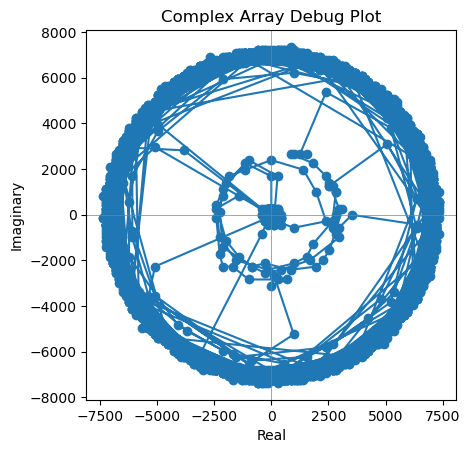

In [8]:
import numpy as np
import matplotlib.pyplot as plt

z = iq[5000:50000]

plt.plot(z.real, z.imag, marker='o')
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.gca().set_aspect('equal')
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title("Complex Array Debug Plot")
plt.show()


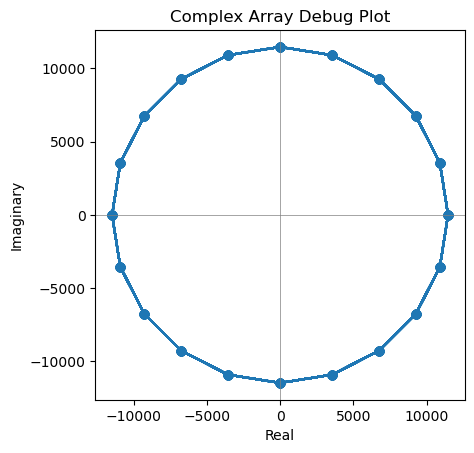

In [81]:
import numpy as np
import matplotlib.pyplot as plt

z = iq_base[:1000]

plt.plot(z.real, z.imag, marker='o')
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.gca().set_aspect('equal')
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title("Complex Array Debug Plot")
plt.show()

ValueError: x and y must have same first dimension, but have shapes (1048576,) and (16777216,)

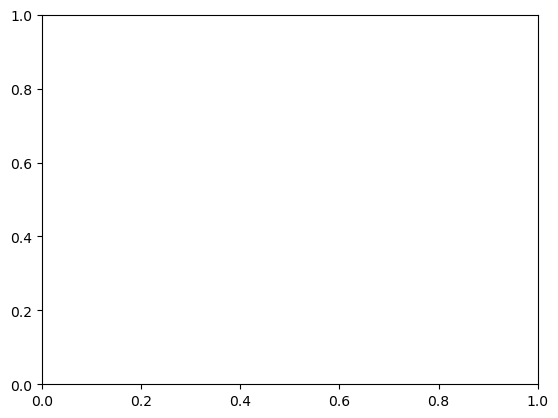

In [65]:
import numpy as np
import matplotlib.pyplot as plt

data = iq

x = range(0, data.shape[0], 1)

plt.plot(x, iq_base.real, label="Real part")
plt.plot(x, iq_base.imag, label="Imaginary part")
plt.legend()
plt.xlabel("x")
plt.ylabel("Value")
plt.show()


In [63]:
x

array([0.])

In [37]:
iq[:2**int(math.log(iq.shape[0], 2))].shape

(1048576,)

In [43]:
np.min(iq)

np.complex128(-819+119j)

In [44]:
np.max(iq)

np.complex128(803+119j)

In [18]:
sdr.tx_destroy_buffer()

In [8]:
print(iq.dtype, iq.shape)
print("I peak:", np.max(np.abs(iq.real)), "Q peak:", np.max(np.abs(iq.imag)))


complex128 (1114112,)
I peak: 880.0 Q peak: 864.0


In [16]:
iq

array([  0. -1.j, -16. -1.j,   0. -1.j, ..., -16.+16.j,   0. +0.j,
         0.+16.j], shape=(1114112,))

In [22]:
import numpy as np
import adi
import time

def read_urh_complex32s_int16(path, byte_order="little"):
    """
    URH complex32s: interleaved int16 IQ: I0,Q0,I1,Q1,...
    Returns complex64 made from int16 to keep pyadi-iio happy.
    """
    dt = np.dtype("<i2") if byte_order == "little" else np.dtype(">i2")
    raw = np.fromfile(path, dtype=dt)
    if raw.size < 2:
        raise ValueError("Empty/too small file")

    if raw.size % 2:
        raw = raw[:-1]

    i = raw[0::2].astype(np.int16)
    q = raw[1::2].astype(np.int16)
    # use complex64 container (values are int16-scale)
    return (i.astype(np.float32) + 1j * q.astype(np.float32)).astype(np.complex64)

def scale_to_pluto_14bit(iq, headroom=0.9):
    """
    Scale IQ so max(|I|,|Q|) <= headroom*(2^13-1).
    Works on complex64 whose values are currently int16-ish scale.
    """
    max_allowed = (2**13 - 1) * headroom  # ~8191*headroom
    peak_i = float(np.max(np.abs(iq.real))) if iq.size else 1.0
    peak_q = float(np.max(np.abs(iq.imag))) if iq.size else 1.0
    peak = max(peak_i, peak_q, 1.0)

    if peak <= max_allowed:
        return iq

    return iq * (max_allowed / peak)

def pick_cyclic_segment(iq, n_complex=262144):
    """
    Pluto cyclic TX is happiest with moderate buffer sizes.
    Take the first n_complex samples (or tile if shorter).
    """
    if iq.size == 0:
        raise ValueError("No samples")
    if iq.size >= n_complex:
        return iq[:n_complex].copy()
    # if file shorter, repeat to reach desired length
    reps = int(np.ceil(n_complex / iq.size))
    tiled = np.tile(iq, reps)
    return tiled[:n_complex].copy()

def pluto_tx_cyclic(iq,
                    uri="ip:pluto.local",
                    center_hz=900_000_000,
                    sample_rate=2_000_000,
                    rf_bandwidth=1_000_000,
                    tx_gain_db=-30):
    sdr = adi.Pluto(uri)

    # configure TX
    sdr.sample_rate = int(sample_rate)
    sdr.tx_lo = int(center_hz)
    sdr.tx_rf_bandwidth = int(rf_bandwidth)
    sdr.tx_hardwaregain_chan0 = float(tx_gain_db)

    # stop previous TX if any
    try:
        sdr.tx_destroy_buffer()
    except Exception:
        pass

    # cyclic on
    sdr.tx_cyclic_buffer = True

    # send
    sdr.tx(iq)

    print("Cyclic TX running. Ctrl+C to stop.")
    print("RF MHz:", center_hz/1e6, "SR:", sample_rate, "Gain dB:", tx_gain_db, "Len:", len(iq))

    try:
        while True:
            time.sleep(1)
    except KeyboardInterrupt:
        pass
    finally:
        sdr.tx_destroy_buffer()




In [42]:
# -------------------
# Usage
# -------------------
URH_FILE = "capture.complex32s"   # <-- change this
URH_FILE = 'PlutoSDR-20260109_163812-2_405GHz-2_1MSps-2_1MHz.complex32s'
BYTE_ORDER = "little"             # usually correct on x86/Linux

iq = read_urh_complex32s_int16(URH_FILE, byte_order=BYTE_ORDER)
iq = iq[:2**14]
print(iq.shape)

# Scale into Pluto's 14-bit-ish range (prevents weird clipping)
iq = scale_to_pluto_14bit(iq, headroom=0.1)

# Use a safe cyclic buffer length (this is the big fix)
iq_loop = pick_cyclic_segment(iq, n_complex=262144)

pluto_tx_cyclic(
    iq_loop,
    center_hz=1_605_000_000,
    sample_rate=2_000_000,     # MUST match URH recording sample rate
    rf_bandwidth=1_000_000,
    tx_gain_db=-40,            # start low then increase
)

(16384,)
Cyclic TX running. Ctrl+C to stop.
RF MHz: 1605.0 SR: 2000000 Gain dB: -40 Len: 262144


In [30]:
iq.shape

(16384,)

In [29]:
iq = iq[:2**14]

In [10]:
import numpy as np
import adi
import time

URI = "ip:pluto.local"

IQ_FILE = 'PlutoSDR-20260109_163812-2_405GHz-2_1MSps-2_1MHz.complex32s' # URH export
BYTE_ORDER = "little"           # try "big" if needed

CENTER_HZ = 1_605_000_000
SAMPLE_RATE = 2_000_000         # MUST match URH capture rate (or it will play at wrong speed)
RF_BW = 1_000_000
TX_GAIN_DB = -30                # start low, increase carefully

# Streaming chunk size (complex samples). Power-of-two is a good idea.
CHUNK = 262144

def read_urh_complex32s(path, byte_order="little"):
    # URH complex32s = interleaved int16: I0,Q0,I1,Q1,...
    dt = np.dtype("<i2") if byte_order == "little" else np.dtype(">i2")
    raw = np.fromfile(path, dtype=dt)
    if raw.size < 2:
        raise ValueError("Empty/too small IQ file")
    if raw.size % 2:
        raw = raw[:-1]
    i = raw[0::2].astype(np.float32)
    q = raw[1::2].astype(np.float32)
    return (i + 1j*q).astype(np.complex64)

def scale_to_pluto(iq, headroom=0.9):
    # Pluto DAC is ~14-bit. We keep peak around 2^13-ish.
    max_allowed = (2**13 - 1) * headroom  # ~8191 * headroom
    peak = max(float(np.max(np.abs(iq.real))), float(np.max(np.abs(iq.imag))), 1.0)
    return iq * (max_allowed / peak)

def make_stream_block(iq, n):
    # Make a block of exactly n complex samples by tiling if needed
    if iq.size >= n:
        return iq[:n].copy()
    reps = int(np.ceil(n / iq.size))
    return np.tile(iq, reps)[:n].copy()

# ---- Load and prepare one repeating block ----
iq = read_urh_complex32s(IQ_FILE, BYTE_ORDER)
iq = scale_to_pluto(iq, headroom=0.9)
block = make_stream_block(iq, CHUNK)

# ---- Pluto TX setup ----
sdr = adi.Pluto(URI)
sdr.sample_rate = int(SAMPLE_RATE)
sdr.tx_lo = int(CENTER_HZ)
sdr.tx_rf_bandwidth = int(RF_BW)
sdr.tx_hardwaregain_chan0 = float(TX_GAIN_DB)

# IMPORTANT: make sure we are NOT in cyclic mode (avoids cyclic buffer errors) :contentReference[oaicite:2]{index=2}
sdr.tx_cyclic_buffer = False

# If a previous cyclic buffer exists from an earlier run, destroy it once
try:
    sdr.tx_destroy_buffer()
except Exception:
    pass

print("Streaming replay (non-cyclic). Ctrl+C to stop.")
print("RF MHz:", CENTER_HZ/1e6, "SR:", SAMPLE_RATE, "Gain dB:", TX_GAIN_DB, "Block:", len(block))

try:
    while True:
        sdr.tx(block)          # keep pushing blocks continuously
        # optional tiny sleep if you want to reduce CPU; usually leave at 0
        time.sleep(0.0)
except KeyboardInterrupt:
    pass
finally:
    try:
        sdr.tx_destroy_buffer()
    except Exception:
        pass


Streaming replay (non-cyclic). Ctrl+C to stop.
RF MHz: 1605.0 SR: 2000000 Gain dB: -30 Block: 262144


In [9]:
block

array([   0.       -8.377159j, -134.03455  -8.377159j,
          0.       -8.377159j, ...,    0.       +0.j      ,
          0.     +125.65739j ,    0.       +0.j      ],
      shape=(262144,), dtype=complex64)

In [28]:
import numpy as np
import adi
import time

URI = "ip:pluto.local"          # try USB URI if possible
IQ_FILE = 'PlutoSDR-20260109_163812-2_405GHz-2_1MSps-2_1MHz.complex32s'
BYTE_ORDER = "little"           # try "big" if needed

CENTER_HZ = 1_605_000_000
SAMPLE_RATE = 2_000_000
RF_BW = 1_000_000
TX_GAIN_DB = -30                # make it visible (careful!)
BLOCK_LEN = 2**14 #65536               # complex samples per block
NUM_BLOCKS = 1024                 # prebuild 16 blocks then loop them

def read_urh_complex32s(path, byte_order="little"):
    dt = np.dtype("<i2") if byte_order == "little" else np.dtype(">i2")
    raw = np.fromfile(path, dtype=dt)
    if raw.size < 2:
        raise ValueError("Empty file")
    if raw.size % 2:
        raw = raw[:-1]
    i = raw[0::2].astype(np.float32)
    q = raw[1::2].astype(np.float32)
    return (i + 1j*q).astype(np.complex64)

def scale_to_pluto_14bit(iq, headroom=0.9):
    # scale into roughly +/-8191 range
    max_allowed = (2**13 - 1) * headroom
    peak = max(float(np.max(np.abs(iq.real))), float(np.max(np.abs(iq.imag))), 1.0)
    return iq * (max_allowed / peak)

# ---- Setup SDR (single owner only!) ----
sdr = adi.Pluto(URI)
sdr.sample_rate = int(SAMPLE_RATE)
sdr.tx_lo = int(CENTER_HZ)
sdr.tx_rf_bandwidth = int(RF_BW)
sdr.tx_hardwaregain_chan0 = float(TX_GAIN_DB)

# HARD reset TX state
sdr.tx_cyclic_buffer = False
try:
    sdr.tx_destroy_buffer()
except Exception:
    pass
time.sleep(0.2)

# ---- Load and prepare blocks ----
iq = read_urh_complex32s(IQ_FILE, BYTE_ORDER)
iq = scale_to_pluto_14bit(iq, headroom=0.1)

need = BLOCK_LEN * NUM_BLOCKS
if iq.size < need:
    reps = int(np.ceil(need / iq.size))
    iq = np.tile(iq, reps)

iq = iq[:need].copy()
blocks = [iq[i*BLOCK_LEN:(i+1)*BLOCK_LEN].copy() for i in range(NUM_BLOCKS)]

print(f"Prepared {NUM_BLOCKS} blocks of {BLOCK_LEN} samples each.")
print("Streaming blocks forever. Ctrl+C to stop.")

# ---- TX forever (prints to prove it's looping) ----
k = 0
try:
    while True:
        for b in blocks:
            sdr.tx(b)
            #print(np.min(b))
            k += 1
            if (k % 100) == 0:
                print("TX blocks sent:", k)
except KeyboardInterrupt:
    pass
finally:
    try:
        sdr.tx_destroy_buffer()
    except Exception:
        pass


Prepared 1024 blocks of 16384 samples each.
Streaming blocks forever. Ctrl+C to stop.
TX blocks sent: 100
TX blocks sent: 200
TX blocks sent: 300
TX blocks sent: 400
TX blocks sent: 500


In [12]:
need

262144

In [29]:
iq[:50]

array([  0.       -0.93079543j, -14.892727 -0.93079543j,
         0.       -0.93079543j,  13.961931 -0.93079543j,
         0.      -15.823523j  , -14.892727 -0.93079543j,
         0.       -0.93079543j, -14.892727 -0.93079543j,
       -14.892727-15.823523j  ,   0.      +13.031136j  ,
         0.      +13.031136j  ,   0.      +13.031136j  ,
         0.       -0.93079543j,  13.961931+13.031136j  ,
        13.961931 -0.93079543j,   0.       -0.93079543j,
        13.961931+13.031136j  , -14.892727+13.031136j  ,
         0.       -0.93079543j,  13.961931-15.823523j  ,
         0.       -0.93079543j,   0.       -0.93079543j,
        13.961931-15.823523j  ,   0.      -15.823523j  ,
        13.961931+13.031136j  ,   0.       -0.93079543j,
        13.961931 -0.93079543j,  13.961931+13.031136j  ,
       -14.892727 -0.93079543j,   0.       -0.93079543j,
       -14.892727 -0.93079543j,  13.961931 -0.93079543j,
        13.961931+13.031136j  ,   0.       -0.93079543j,
         0.       -0.93079543j,

RX LO 2000000000


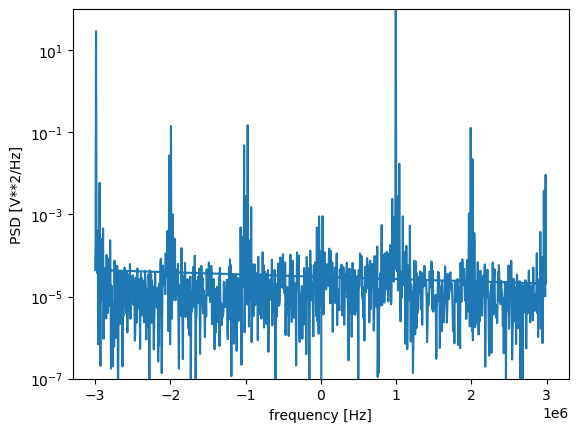

In [4]:
# Copyright (C) 2022 Analog Devices, Inc.
#
# SPDX short identifier: ADIBSD

import time

import adi
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

# Create radio
sdr = adi.Pluto(uri="ip:pluto.local"   )

# Configure properties
sdr.rx_rf_bandwidth = 4000000
sdr.sample_rate = 6000000
sdr.rx_lo = 2000000000
sdr.tx_lo = 2000000000
sdr.tx_cyclic_buffer = True
sdr.tx_hardwaregain_chan0 = -30
sdr.gain_control_mode_chan0 = "slow_attack"

# Configuration data channels
sdr.rx_enabled_channels = [0]
sdr.tx_enabled_channels = [0]

# Read properties
print("RX LO %s" % (sdr.rx_lo))

# Create a sinewave waveform
fs = int(sdr.sample_rate)
N = 1024
fc = int(1000000 / (fs / N)) * (fs / N)
ts = 1 / float(fs)
t = np.arange(0, N * ts, ts)
i = np.cos(2 * np.pi * t * fc) * 2 ** 14
q = np.sin(2 * np.pi * t * fc) * 2 ** 14
iq = i + 1j * q

# Send data
sdr.tx(iq)

# Collect data
for r in range(1):
    x = sdr.rx()
    f, Pxx_den = signal.periodogram(x, fs)
    plt.clf()
    plt.semilogy(f, Pxx_den)
    plt.ylim([1e-7, 1e2])
    plt.xlabel("frequency [Hz]")
    plt.ylabel("PSD [V**2/Hz]")
    plt.draw()
    plt.pause(0.05)
    time.sleep(0.1)

plt.show()
sdr.tx_destroy_buffer()

In [6]:
iq.shape

(1024,)

[ 0.+0.j  0.+0.j -1.+0.j ...  0.+0.j  0.+0.j  0.-1.j]


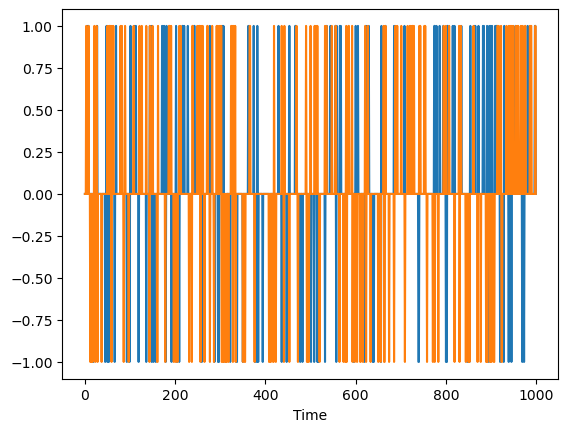

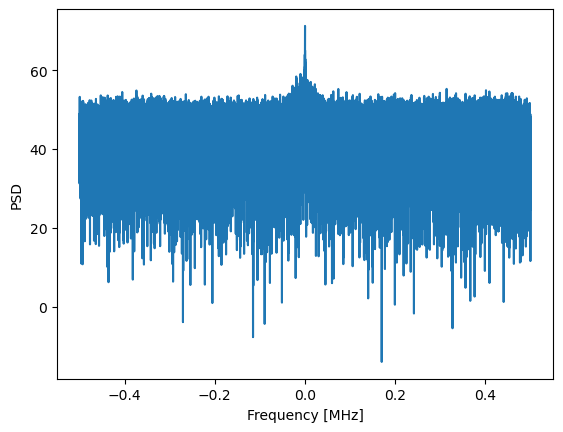

In [8]:
import numpy as np
import adi
import matplotlib.pyplot as plt

sample_rate = 1e6 # Hz
center_freq = 915e6 # Hz
num_samps = 100000 # number of samples per call to rx()

sdr = adi.Pluto("ip:pluto.local")
sdr.sample_rate = int(sample_rate)

# Config Tx
sdr.tx_rf_bandwidth = int(sample_rate) # filter cutoff, just set it to the same as sample rate
sdr.tx_lo = int(center_freq)
sdr.tx_hardwaregain_chan0 = -50 # Increase to increase tx power, valid range is -90 to 0 dB

# Config Rx
sdr.rx_lo = int(center_freq)
sdr.rx_rf_bandwidth = int(sample_rate)
sdr.rx_buffer_size = num_samps
sdr.gain_control_mode_chan0 = 'manual'
sdr.rx_hardwaregain_chan0 = 0.0 # dB, increase to increase the receive gain, but be careful not to saturate the ADC

# Create transmit waveform (QPSK, 16 samples per symbol)
num_symbols = 1000
x_int = np.random.randint(0, 4, num_symbols) # 0 to 3
x_degrees = x_int*360/4.0 + 45 # 45, 135, 225, 315 degrees
x_radians = x_degrees*np.pi/180.0 # sin() and cos() takes in radians
x_symbols = np.cos(x_radians) + 1j*np.sin(x_radians) # this produces our QPSK complex symbols
samples = np.repeat(x_symbols, 16) # 16 samples per symbol (rectangular pulses)
samples *= 2**14 # The PlutoSDR expects samples to be between -2^14 and +2^14, not -1 and +1 like some SDRs

# Start the transmitter
sdr.tx_cyclic_buffer = True # Enable cyclic buffers
sdr.tx(samples) # start transmitting

# Clear buffer just to be safe
for i in range (0, 10):
    raw_data = sdr.rx()

# Receive samples
rx_samples = sdr.rx()
print(rx_samples)

# Stop transmitting
sdr.tx_destroy_buffer()

# Calculate power spectral density (frequency domain version of signal)
psd = np.abs(np.fft.fftshift(np.fft.fft(rx_samples)))**2
psd_dB = 10*np.log10(psd)
f = np.linspace(sample_rate/-2, sample_rate/2, len(psd))

# Plot time domain
plt.figure(0)
plt.plot(np.real(rx_samples[::100]))
plt.plot(np.imag(rx_samples[::100]))
plt.xlabel("Time")

# Plot freq domain
plt.figure(1)
plt.plot(f/1e6, psd_dB)
plt.xlabel("Frequency [MHz]")
plt.ylabel("PSD")
plt.show()